<a href="https://colab.research.google.com/github/main-polyboly/CienciaDeDatos-GestiondeCitas/blob/main/MIS_CITAMED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CITAMED 2.0 — Sistema de Información Gerencial (MIS)
### Dashboard de KPIs — Datos Reales del TPS
**Curso:** Introducción a los Sistemas de Información  
**Datos:** 6,002 citas | 30,001 pacientes | 502 médicos | 2,703 facturas


## kpis

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#2d3561', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#a0a0a0', 'ytick.color': '#a0a0a0',
    'text.color': '#e0e0e0', 'grid.color': '#2d3561',
    'grid.linewidth': 0.5, 'font.family': 'DejaVu Sans', 'font.size': 10,
})
ACCENT = ['#4fc3f7','#81c784','#ffb74d','#f06292','#ba68c8',
          '#4db6ac','#ff8a65','#a5d6a7','#90caf9','#fff176',
          '#ef9a9a','#ce93d8','#80cbc4','#ffe082','#b0bec5']
BLUE, GREEN, ORANGE, RED, PURPLE = '#4fc3f7','#81c784','#ffb74d','#ef5350','#ba68c8'

# EXTRACCIÓN
BASE = '/content/drive/MyDrive/Colab Notebooks/'

# Facturas: los decimales vienen con coma → necesitan limpieza
import csv, io

def leer_facturas(path):
    rows_fixed = []
    with open(path, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        header = next(reader)
        for row in reader:
            row = [r.strip() for r in row]

            fixed_part = row[:7]
            middle_part = row[7:-3] # These are the columns with potential commas
            tail_part = row[-3:]

            cleaned_middle = []
            for item in middle_part:
                # Replace comma with dot for decimal conversion
                cleaned_middle.append(item.replace(',', '.'))

            combined_row = fixed_part + cleaned_middle + tail_part
            rows_fixed.append(combined_row)
    return pd.DataFrame(rows_fixed, columns=header)

citas     = pd.read_csv(BASE + 'citas.csv')
facturas  = leer_facturas(BASE + 'facturas.csv')
medicos   = pd.read_csv(BASE + 'medicos.csv')
pacientes = pd.read_csv(BASE + 'pacientes.csv')
recetas   = pd.read_csv(BASE + 'recetas.csv')

# ── TRANSFORMACIÓN ────────────────────────────────────────────
citas['Fecha']            = pd.to_datetime(citas['Fecha'])
facturas['Fecha_Cita']    = pd.to_datetime(facturas['Fecha_Cita'])
facturas['Subtotal']      = pd.to_numeric(facturas['Subtotal'])
facturas['IVA_15']        = pd.to_numeric(facturas['IVA_15'])
facturas['Total']         = pd.to_numeric(facturas['Total'])
citas['Mes']              = citas['Fecha'].dt.to_period('M').astype(str)
citas['Anio']             = citas['Fecha'].dt.year
facturas['Mes']           = facturas['Fecha_Cita'].dt.to_period('M').astype(str)
facturas['Anio']          = facturas['Fecha_Cita'].dt.year

fact_pag = facturas[facturas['Estado_Pago'] == 'Pagada']

# KPIs base
total_citas      = len(citas)
completadas      = (citas['Estado'] == 'Completada').sum()
canceladas       = (citas['Estado'] == 'Cancelada').sum()
no_asistio       = (citas['Estado'] == 'No asistió').sum()
tasa_comp        = completadas / total_citas * 100
tasa_canc        = canceladas  / total_citas * 100
total_recaudado  = fact_pag['Total'].sum()
ticket_prom      = fact_pag['Total'].mean()
total_pendiente  = facturas[facturas['Estado_Pago']=='Pendiente']['Total'].sum()

print(f"   Citas:            {total_citas:,}")
print(f"   Completadas:      {completadas:,} ({tasa_comp:.1f}%)")
print(f"   Canceladas:       {canceladas:,} ({tasa_canc:.1f}%)")
print(f"   No asistió:       {no_asistio:,}")
print(f"   Pacientes:        {len(pacientes):,}")
print(f"   Médicos:          {len(medicos):,}")
print(f"   Total recaudado:  ${total_recaudado:,.2f}")
print(f"   Ticket promedio:  ${ticket_prom:.2f}")
print(f"   Por cobrar:       ${total_pendiente:,.2f}")

   Citas:            6,002
   Completadas:      2,703 (45.0%)
   Canceladas:       722 (12.0%)
   No asistió:       463
   Pacientes:        30,001
   Médicos:          502
   Total recaudado:  $179,913.60
   Ticket promedio:  $78.84
   Por cobrar:       $21,241.79


In [10]:
!ls '/content/drive/MyDrive/Colab Notebooks/'

'01_IntroPython_ TapiaBarbara.ipynb.'   medicos.cred
 admin.cred			        medicos.csv
 admin.csv			       'MIS_CITAMED (1).ipynb'
 auditoria.csv			        MIS_CITAMED.ipynb
 BaseDatos_SistemaCitas.xlsx	        notas_credito.csv
 citas.csv			        pacientes.cred
 entradas_historial.csv		        pacientes.csv
 facturas.csv			        recetas.csv
 historiales.csv		        Untitled0.ipynb
 items_receta.csv


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dashboard 1 — Panel Ejecutivo (KPIs 1–5)

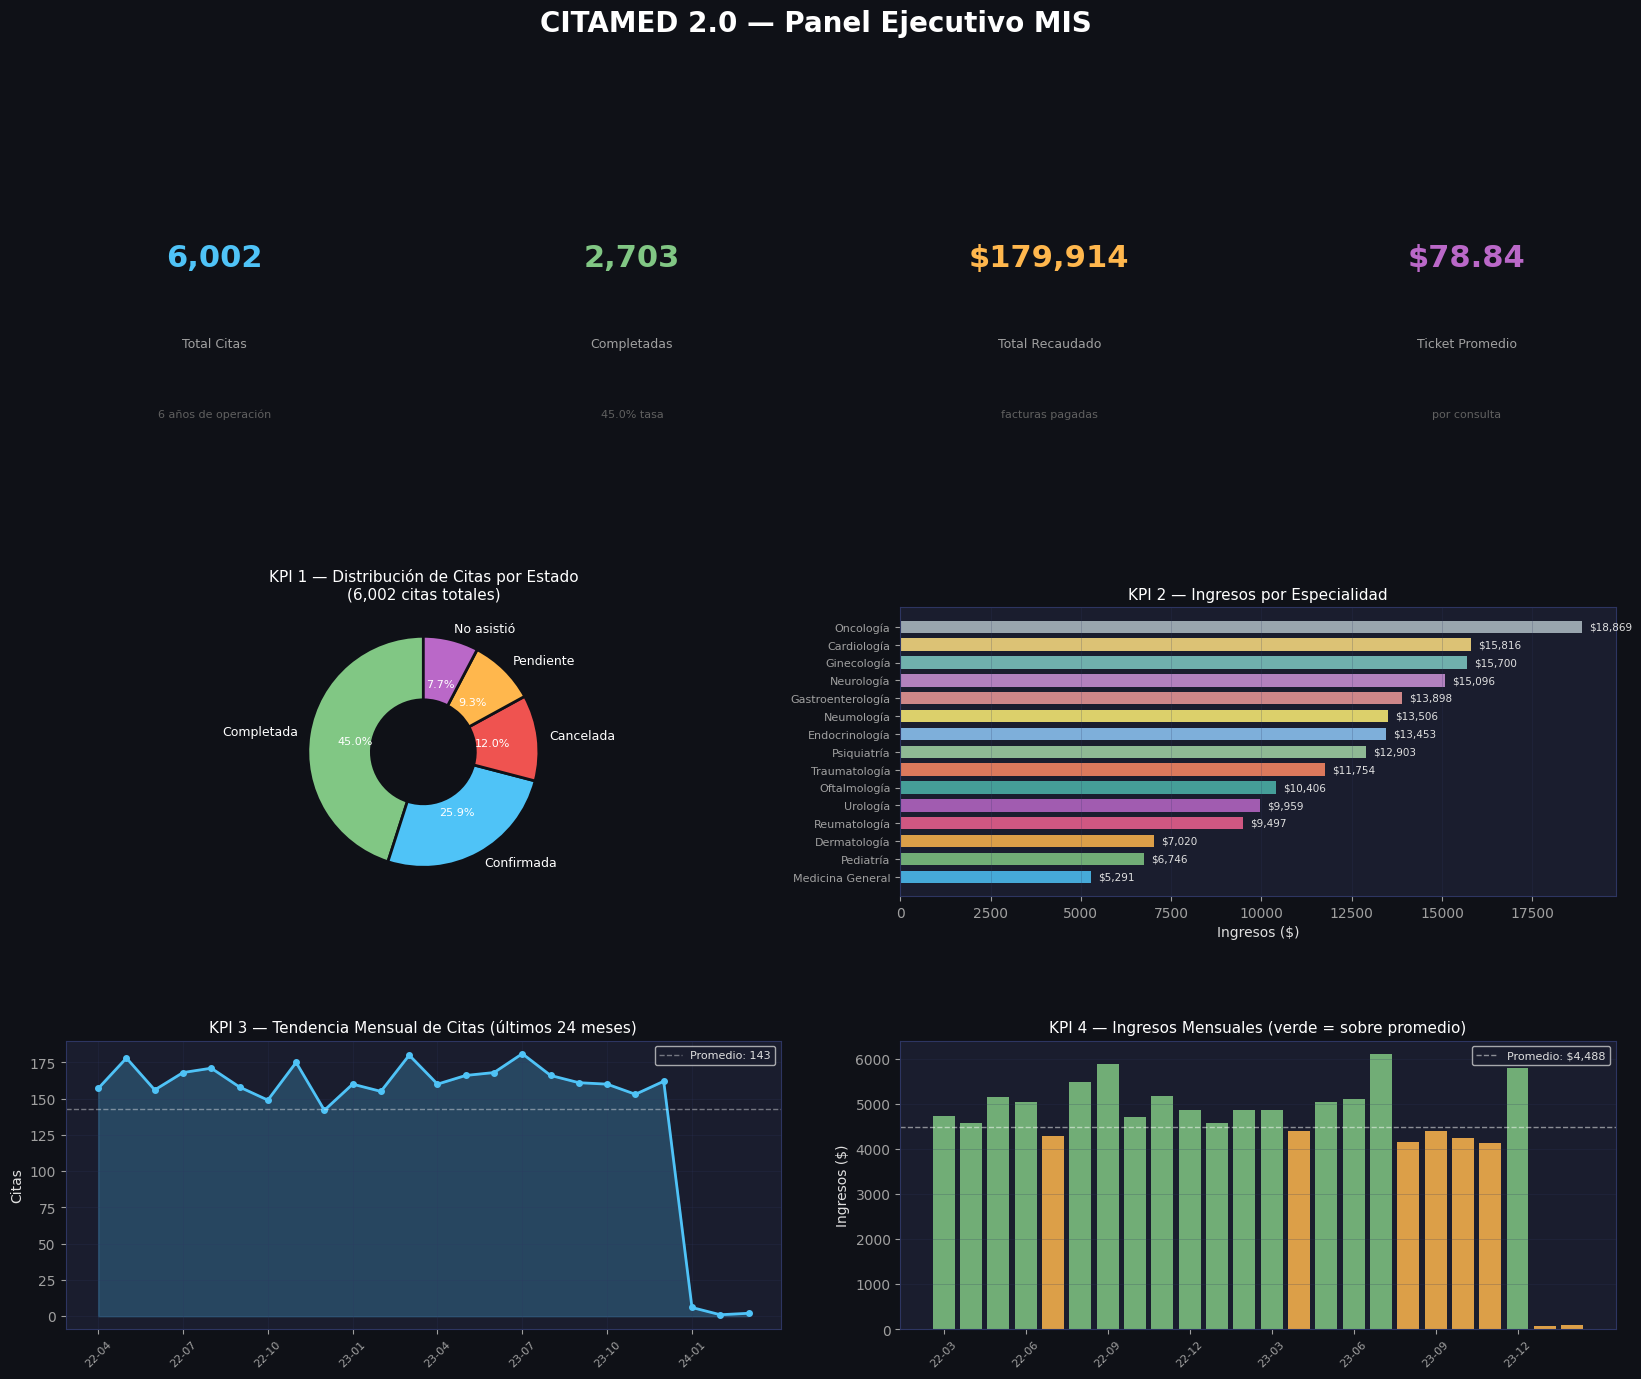

Dashboard Ejecutivo guardado


In [16]:
fig = plt.figure(figsize=(20, 15), facecolor='#0f1117')
fig.suptitle('CITAMED 2.0 — Panel Ejecutivo MIS', fontsize=20, fontweight='bold', color='white', y=0.99)
gs = GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)

# ── Tarjetas KPI ──────────────────────────────────────────────
metricas = [
    ('Total Citas',        f'{total_citas:,}',        BLUE,   '6 años de operación'),
    ('Completadas',        f'{completadas:,}',         GREEN,  f'{tasa_comp:.1f}% tasa'),
    ('Total Recaudado',    f'${total_recaudado:,.0f}', ORANGE, 'facturas pagadas'),
    ('Ticket Promedio',    f'${ticket_prom:.2f}',      PURPLE, 'por consulta'),
]
for i, (titulo, valor, color, sub) in enumerate(metricas):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor('#1a1d2e'); ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color(color); spine.set_linewidth(3)
    ax.text(0.5, 0.68, valor,  ha='center', fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.40, titulo, ha='center', fontsize=9,  color='#a0a0a0')
    ax.text(0.5, 0.16, sub,    ha='center', fontsize=8,  color='#606060')

# ── KPI 1: Estado de citas (donut) ────────────────────────────
ax1 = fig.add_subplot(gs[1, 0:2])
estados = citas['Estado'].value_counts()
color_map = {'Completada': GREEN, 'Cancelada': RED, 'Confirmada': BLUE,
             'Pendiente': ORANGE, 'No asistió': PURPLE}
colores = [color_map.get(e, '#888') for e in estados.index]
wedges, texts, autotexts = ax1.pie(
    estados.values, labels=estados.index, colors=colores, autopct='%1.1f%%',
    startangle=90, wedgeprops={'width':0.55, 'edgecolor':'#0f1117', 'linewidth':2},
    textprops={'fontsize':9, 'color':'white'})
for at in autotexts: at.set_fontsize(8)
ax1.set_title('KPI 1 — Distribución de Citas por Estado\n(6,002 citas totales)', color='white', fontsize=11)
ax1.set_facecolor('#1a1d2e')

# ── KPI 2: Ingresos por especialidad ─────────────────────────
ax2 = fig.add_subplot(gs[1, 2:4])
ing_esp = fact_pag.groupby('Especialidad')['Total'].sum().sort_values()
bars = ax2.barh(range(len(ing_esp)), ing_esp.values, color=ACCENT[:len(ing_esp)], alpha=0.85, height=0.7)
ax2.set_yticks(range(len(ing_esp)))
ax2.set_yticklabels([e[:20] for e in ing_esp.index], fontsize=8)
ax2.set_xlabel('Ingresos ($)')
ax2.set_title('KPI 2 — Ingresos por Especialidad', color='white', fontsize=11)
ax2.grid(axis='x', alpha=0.3)
for i, v in enumerate(ing_esp.values):
    ax2.text(v + 200, i, f'${v:,.0f}', va='center', fontsize=7.5, color='#e0e0e0')

# ── KPI 3: Tendencia mensual últimos 24 meses ─────────────────
ax3 = fig.add_subplot(gs[2, 0:2])
tend = citas.groupby('Mes').size().reset_index(name='Citas').sort_values('Mes').tail(24)
x = range(len(tend))
ax3.fill_between(x, tend['Citas'], alpha=0.25, color=BLUE)
ax3.plot(x, tend['Citas'], 'o-', color=BLUE, linewidth=2, markersize=4)
ax3.axhline(tend['Citas'].mean(), color='white', linestyle='--', linewidth=1, alpha=0.4, label=f'Promedio: {tend["Citas"].mean():.0f}')
ax3.set_xticks(range(0, len(tend), 3))
ax3.set_xticklabels([tend.iloc[i]['Mes'][-5:] for i in range(0, len(tend), 3)], rotation=45, fontsize=8)
ax3.set_ylabel('Citas')
ax3.set_title('KPI 3 — Tendencia Mensual de Citas (últimos 24 meses)', color='white', fontsize=11)
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# ── KPI 4: Ingresos mensuales ─────────────────────────────────
ax4 = fig.add_subplot(gs[2, 2:4])
ing_mes = fact_pag.groupby('Mes')['Total'].sum().reset_index().sort_values('Mes').tail(24)
prom_ing = ing_mes['Total'].mean()
cols_bar = [GREEN if v >= prom_ing else ORANGE for v in ing_mes['Total']]
ax4.bar(range(len(ing_mes)), ing_mes['Total'], color=cols_bar, alpha=0.85)
ax4.axhline(prom_ing, color='white', linestyle='--', linewidth=1, alpha=0.5, label=f'Promedio: ${prom_ing:,.0f}')
ax4.set_xticks(range(0, len(ing_mes), 3))
ax4.set_xticklabels([ing_mes.iloc[i]['Mes'][-5:] for i in range(0, len(ing_mes), 3)], rotation=45, fontsize=8)
ax4.set_ylabel('Ingresos ($)')
ax4.set_title('KPI 4 — Ingresos Mensuales (verde = sobre promedio)', color='white', fontsize=11)
ax4.legend(fontsize=8); ax4.grid(axis='y', alpha=0.3)

for ax in [ax1,ax2,ax3,ax4]: ax.set_facecolor('#1a1d2e')

plt.savefig(BASE + 'dashboard_ejecutivo.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Dashboard Ejecutivo guardado")

## Dashboard 2 — Análisis Operacional (KPIs 5–8)

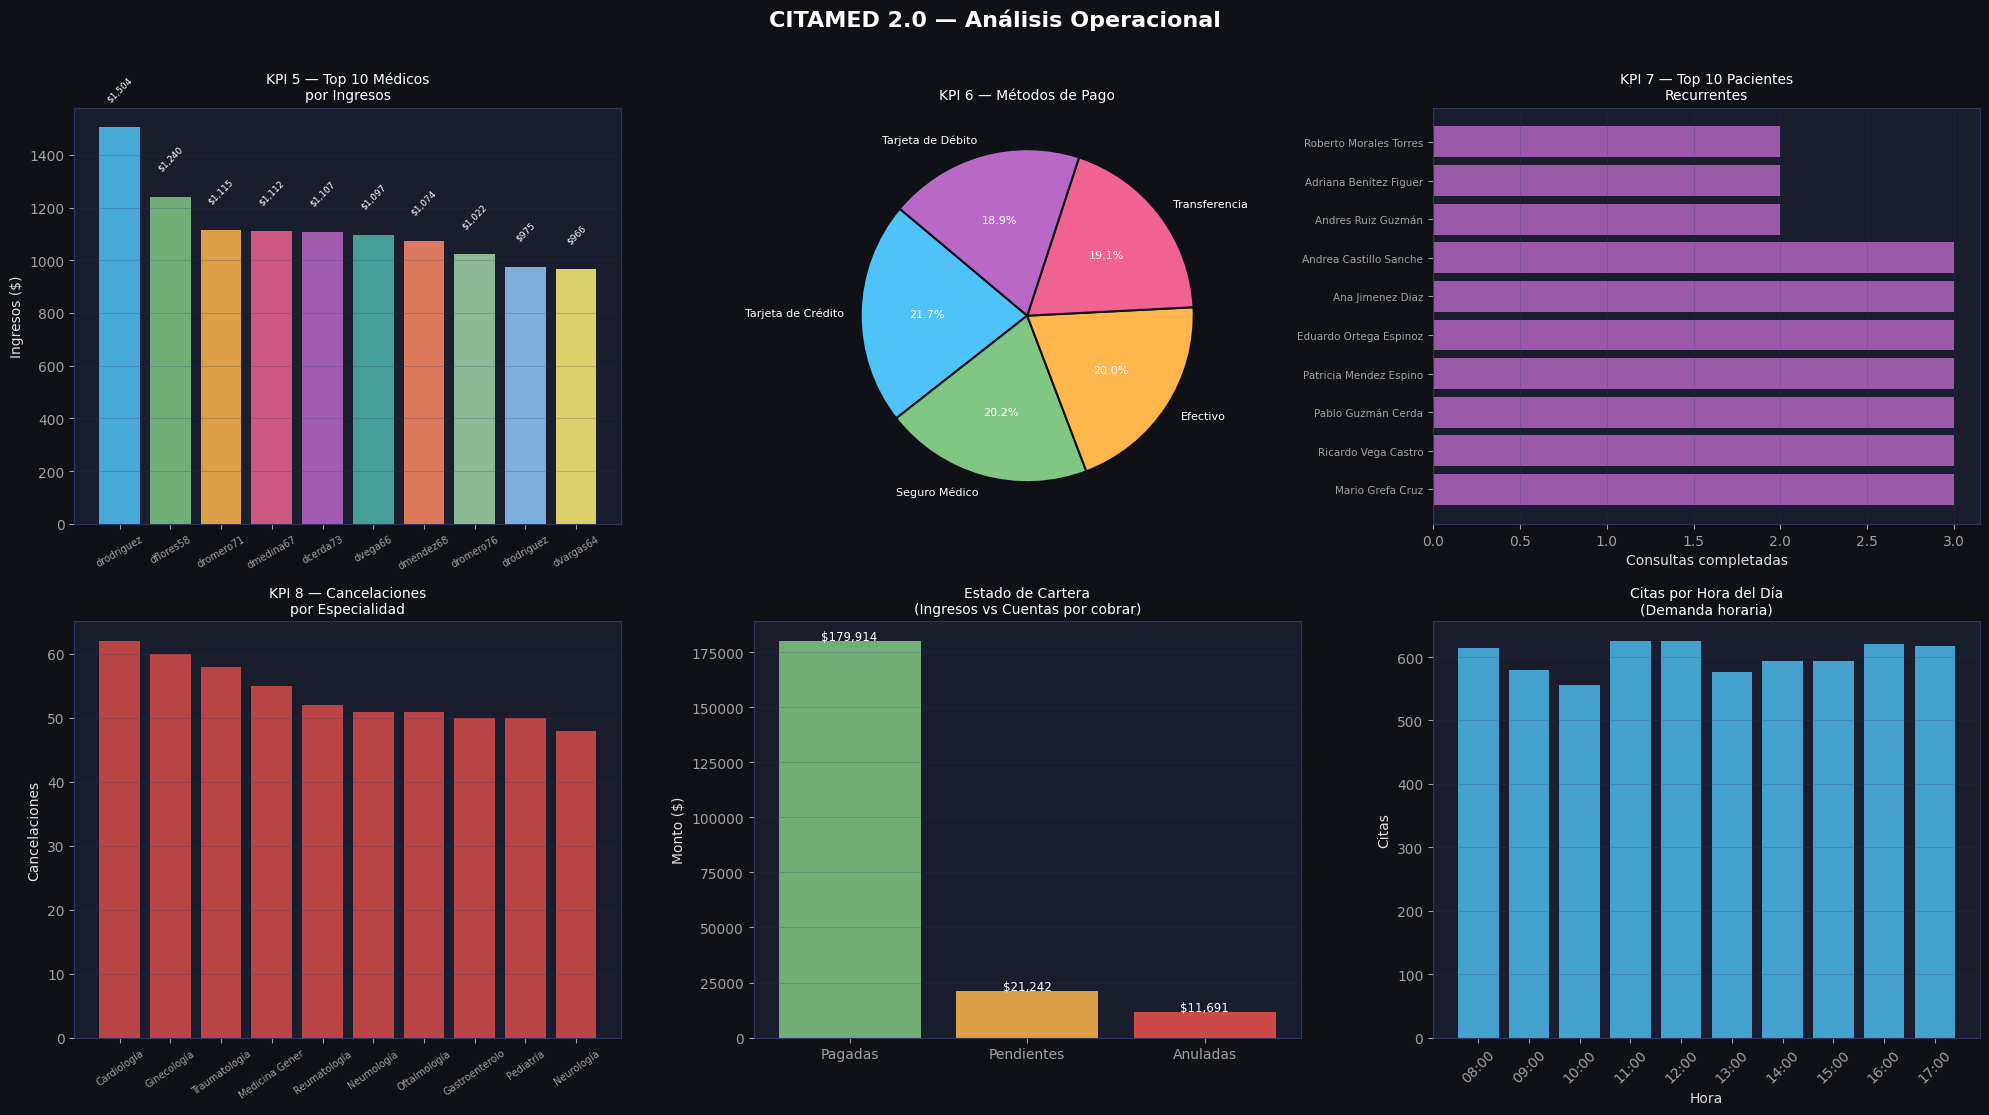

Dashboard Operacional guardado


In [15]:
fig2, axes = plt.subplots(2, 3, figsize=(20, 11), facecolor='#0f1117')
fig2.suptitle('CITAMED 2.0 — Análisis Operacional', fontsize=16, fontweight='bold', color='white', y=1.01)

# ── KPI 5: Top 10 médicos por ingresos ────────────────────────
ax = axes[0, 0]
top_med = fact_pag.groupby('Medico_Username')['Total'].sum().sort_values(ascending=False).head(10)
ax.bar(range(len(top_med)), top_med.values, color=ACCENT[:10], alpha=0.85)
ax.set_xticks(range(len(top_med)))
ax.set_xticklabels([m[:10] for m in top_med.index], rotation=30, fontsize=7)
ax.set_ylabel('Ingresos ($)')
ax.set_title('KPI 5 — Top 10 Médicos\npor Ingresos', color='white', fontsize=10)
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(top_med.values):
    ax.text(i, v+100, f'${v:,.0f}', ha='center', fontsize=6.5, color='white', rotation=45)

# ── KPI 6: Métodos de pago ────────────────────────────────────
ax = axes[0, 1]
metodo = fact_pag['MetodoPago'].value_counts()
wedges, texts, autotexts = ax.pie(
    metodo.values, labels=metodo.index, colors=ACCENT[:len(metodo)],
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor':'#0f1117', 'linewidth':1.5},
    textprops={'fontsize':8, 'color':'white'})
for at in autotexts: at.set_fontsize(8)
ax.set_title('KPI 6 — Métodos de Pago', color='white', fontsize=10)

# ── KPI 7: Top pacientes recurrentes ─────────────────────────
ax = axes[0, 2]
top_pac = citas[citas['Estado']=='Completada']['Nombre_Paciente'].value_counts().head(10)
ax.barh(range(len(top_pac)), top_pac.values, color=PURPLE, alpha=0.8)
ax.set_yticks(range(len(top_pac)))
ax.set_yticklabels([n[:22] for n in top_pac.index], fontsize=7.5)
ax.set_xlabel('Consultas completadas')
ax.set_title('KPI 7 — Top 10 Pacientes\nRecurrentes', color='white', fontsize=10)
ax.grid(axis='x', alpha=0.3)

# ── KPI 8: Tasa cancelación por especialidad ─────────────────
ax = axes[1, 0]
canc_esp = citas[citas['Estado']=='Cancelada']['Especialidad'].value_counts().head(10)
ax.bar(range(len(canc_esp)), canc_esp.values, color=RED, alpha=0.75)
ax.set_xticks(range(len(canc_esp)))
ax.set_xticklabels([e[:14] for e in canc_esp.index], rotation=35, fontsize=7)
ax.set_ylabel('Cancelaciones')
ax.set_title('KPI 8 — Cancelaciones\npor Especialidad', color='white', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# ── Estado de cartera ─────────────────────────────────────────
ax = axes[1, 1]
cartera_labels = ['Pagadas', 'Pendientes', 'Anuladas']
cartera_vals = [
    fact_pag['Total'].sum(),
    facturas[facturas['Estado_Pago']=='Pendiente']['Total'].sum(),
    facturas[facturas['Estado_Pago']=='Anulada']['Total'].sum() if 'Anulada' in facturas['Estado_Pago'].values else 0
]
bars2 = ax.bar(cartera_labels, cartera_vals, color=[GREEN, ORANGE, RED], alpha=0.85)
ax.set_ylabel('Monto ($)')
ax.set_title('Estado de Cartera\n(Ingresos vs Cuentas por cobrar)', color='white', fontsize=10)
ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars2, cartera_vals):
    ax.text(b.get_x()+b.get_width()/2, v+500, f'${v:,.0f}', ha='center', fontsize=8.5, color='white')

# ── Citas por hora del día ────────────────────────────────────
ax = axes[1, 2]
horas = citas['Hora'].value_counts().sort_index()
ax.bar(horas.index, horas.values, color=BLUE, alpha=0.8)
ax.set_xlabel('Hora'); ax.set_ylabel('Citas')
ax.set_title('Citas por Hora del Día\n(Demanda horaria)', color='white', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)

for row in axes:
    for a in row: a.set_facecolor('#1a1d2e')

plt.tight_layout()
plt.savefig(BASE + 'dashboard_operacional.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Dashboard Operacional guardado")

## Reporte Programado — Routine Report

In [17]:
from datetime import date

mes_actual = date.today().strftime('%Y-%m')
df_mes_c = citas[citas['Mes'] == mes_actual]
df_mes_f = fact_pag[fact_pag['Mes'] == mes_actual]

print(f"{'═'*55}")
print(f"  📋 REPORTE MENSUAL — {mes_actual}")
print(f"{'═'*55}")
print(f"  Citas agendadas        : {len(df_mes_c)}")
print(f"  Citas completadas      : {(df_mes_c['Estado']=='Completada').sum()}")
print(f"  Citas canceladas       : {(df_mes_c['Estado']=='Cancelada').sum()}")
print(f"  Ingresos del mes       : ${df_mes_f['Total'].sum():,.2f}")
print(f"  Transacciones pagadas  : {len(df_mes_f)}")
if len(df_mes_f) > 0:
    print(f"  Ticket promedio        : ${df_mes_f['Total'].mean():.2f}")
    print(f"  Especialidad líder     : {df_mes_f.groupby('Especialidad')['Total'].sum().idxmax()}")
print(f"{'═'*55}")
print()
print(f"  📊 RESUMEN ACUMULADO TOTAL")
print(f"{'═'*55}")
print(f"  Pacientes registrados  : {len(pacientes):,}")
print(f"  Médicos activos        : {len(medicos):,}")
print(f"  Total citas            : {total_citas:,}")
print(f"  Tasa completadas       : {tasa_comp:.1f}%")
print(f"  Tasa cancelación       : {tasa_canc:.1f}%")
print(f"  Total recaudado        : ${total_recaudado:,.2f}")
print(f"  Por cobrar             : ${total_pendiente:,.2f}")
print(f"  Ticket promedio        : ${ticket_prom:.2f}")
print(f"{'═'*55}")


═══════════════════════════════════════════════════════
  📋 REPORTE MENSUAL — 2026-05
═══════════════════════════════════════════════════════
  Citas agendadas        : 1
  Citas completadas      : 1
  Citas canceladas       : 0
  Ingresos del mes       : $0.00
  Transacciones pagadas  : 0
═══════════════════════════════════════════════════════

  📊 RESUMEN ACUMULADO TOTAL
═══════════════════════════════════════════════════════
  Pacientes registrados  : 30,001
  Médicos activos        : 502
  Total citas            : 6,002
  Tasa completadas       : 45.0%
  Tasa cancelación       : 12.0%
  Total recaudado        : $179,913.60
  Por cobrar             : $21,241.79
  Ticket promedio        : $78.84
═══════════════════════════════════════════════════════


## Propuesta de Valor del MIS — CITAMED 2.0

| # | KPI | Pregunta Gerencial que Responde | Decisión que Habilita |
|---|-----|--------------------------------|----------------------|
| 1 | Distribución de citas por estado | ¿Cuántas citas se concretan vs. se pierden? | Mejorar procesos de confirmación |
| 2 | Ingresos por especialidad | ¿Cuál es la especialidad más rentable? | Invertir en áreas de alto retorno |
| 3 | Tendencia mensual de citas | ¿Estamos creciendo? ¿Hay estacionalidad? | Planificar personal y recursos |
| 4 | Ingresos mensuales | ¿Qué meses superan el promedio? | Control presupuestal y metas |
| 5 | Top 10 médicos por ingresos | ¿Quiénes son nuestros mejores generadores? | Retención de talento médico |
| 6 | Métodos de pago | ¿Cómo pagan nuestros pacientes? | Optimizar canales de cobro |
| 7 | Pacientes recurrentes | ¿Quiénes son nuestros clientes más leales? | Estrategia de fidelización |
| 8 | Cancelaciones por especialidad | ¿Dónde se pierde más demanda? | Reducir ausentismo focalizado |

### Nuestra ventaja Competitiva
> **Sin MIS:** la gerencia operaria a ciegas con 6,002 citas y $179,913 en transacciones sin visibilidad alguna.  
> **Con MIS:** Las decisiones tácticas y estratégicas son respaldadas por datos en tiempo real.
